In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/data_model_davies'

Mounted at /content/drive


In [2]:
# Numerical parameters
nlat = 78
nlon = 71
nz = 500 # Initial number of rioters

Lr = 6 # most recent time steps in our discretised temporal scheme
Lp = 12 # response lag of the police units

Nt = 500 # Rate at which individuals choose to participate at time t
Ntt = 10

dt = 0.1 # delta time
sim_time = 0.0 # init time

In [3]:
# Simulation parameters

# alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)

## ----- Parámetros optmizados ----- ##
# beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
#         target affects the attractiveness of that target)
# gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
#          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)
# alpha_p: Attractiveness of a location to police. It influences how police resources are allocated based on the characteristics of the location.
# gamma_p: Impact of the number of rioters on the police requirement at a site.

alpha_r = 0.5
beta_r = 0.5
gamma_r = 0.11

mu = 1.0 # This is an exponent in the function for the probability of rioting in an area, related to how deprivation affects the likelihood of rioting



alpha_p = 1.0
gamma_p = 0.01

eta = 0.005 # Infection rate. It determines how quickly individuals are influenced by the ongoing disorder and become active rioters
tau = 0.75 # Arrest rate parameter. It determines how quickly rioters are arrested by police when they are present
Ptotal = 500.0  # Total number of police forces

In [4]:
# Data sources

# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# i: Residential Área
# j: Retail Center (Potential Riot Site)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")  # Ponderated distances (the distance between the centroids of i and j)
Dj_cl= np.loadtxt(f"{FOLDER_PATH}/data_sosafe.dat") # Data from SOSAFE (real data)

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Ai = np.zeros((nlat, nlon), "d")  # Active population
Ci = np.zeros((nlat, nlon), "d")  # Capture rate
rho = np.ones((nlat, nlon), "d")  # Deprivation distribution (is a measure of the deprivation in i)

Rj = np.zeros(nz, "d")  # Rioters (Ri: the number of rioters whose residece in in a given zone i)
# Rj = np.loadtxt('Rj_init.dat') # Initial 100 rioters distribution
Pj = np.zeros(nz, "d")  # Police officers
We_ij = np.zeros((nlat, nlon, nz), "d")  # Benefit computation (We_ij: effective attractiveness)
fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation
Sij = np.zeros((nlat, nlon, nz), "d")  # Population flow between i and j (An estimate of the number of rioters from i who are participating in disorder in j at time t)
Dj = np.zeros(nz, "d")  # The number of rioters in j
Ddel = np.zeros((nz, Lp), "d")  # Police requirement, time-delayed
Dej = np.zeros(nz, "d")

In [5]:
Dj_cl= np.loadtxt(f"{FOLDER_PATH}/data_sosafe.dat")

## Simulation

In [6]:
auxij1 = np.exp(-beta_r * dij)
dij = 1.0 * Zj[:, 2] * auxij1 / np.max(Zj[:, 2])

# Computation loop
counter = 0
idxr = 0
counterp = 0
idxp = 0

In [7]:
print("Starting loop ...")
timer0 = time.time()
t = 0


for nn in range(Nt):
    for mm in range(Ntt):

        fj = np.exp(-np.floor(gamma_r * Pj / (Rj + 1.0e-20))) # 500 Values
        Wij = fj * dij # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
        Wi = np.sum(Wij, axis=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i

        P_off = rho * Wi / (1.0 + Wi) # P_off shape: 78, 71

        # fjdel storage
        idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
        fjdel[:, idxr] = fj # fjdel: 500, 6

        if counter >= Lr:
            dnm = Lr
        else:
            dnm = counter + 1
        # Delayed term computation
        # print (f"Lr: {Lr}, idxr: {idxr}, dnm: {dnm}, counter: {counter}")
        We_ij = np.sum(fjdel, axis=1) * dij / dnm

        # Flow computation step 1i
        auxw = Ai / (np.sum(We_ij, axis=2) + 1.0e-20)

        # Flow computation step 2, this loop must be vectorized
        for jj in range(nz):
            Sij[:, :, jj] = auxw[:, :] * We_ij[:, :, jj]

        # Rioter computation

        Rj = np.sum(np.sum(Sij, axis=1), axis=0)

        # Police Interaction
        Dj[:] = Zj[:, 2] ** (alpha_p) * np.exp(gamma_p * Rj[:])

        # Delayed term computation
        idxp = counter - (Lp) * int(counter / Lp)
        Ddel[:, idxp] = Dj[:]
        if counter >= Lp:
            dnm = Lp
        else:
            dnm = counter + 1

        Dej = np.sum(Ddel, axis=1) / dnm
        Pj = Ptotal * Dej / np.sum(Dej)
        counter += 1

        # Capture rate
        fj = 1.0 - np.exp(-np.floor(Pj / (Rj + 1.0e-20)))
        Ci = tau * np.sum(Sij * fj, axis=2)

        # Time step for Ai and Ii
        Ai += dt * (eta * P_off * Ii - Ci)
        Ii += -dt * eta * P_off * Ii
        t += dt

timer1 = time.time()
print("Total execution time: ", timer1 - timer0)

Starting loop ...
Total execution time:  383.22123527526855


## Gráficos de Comparación

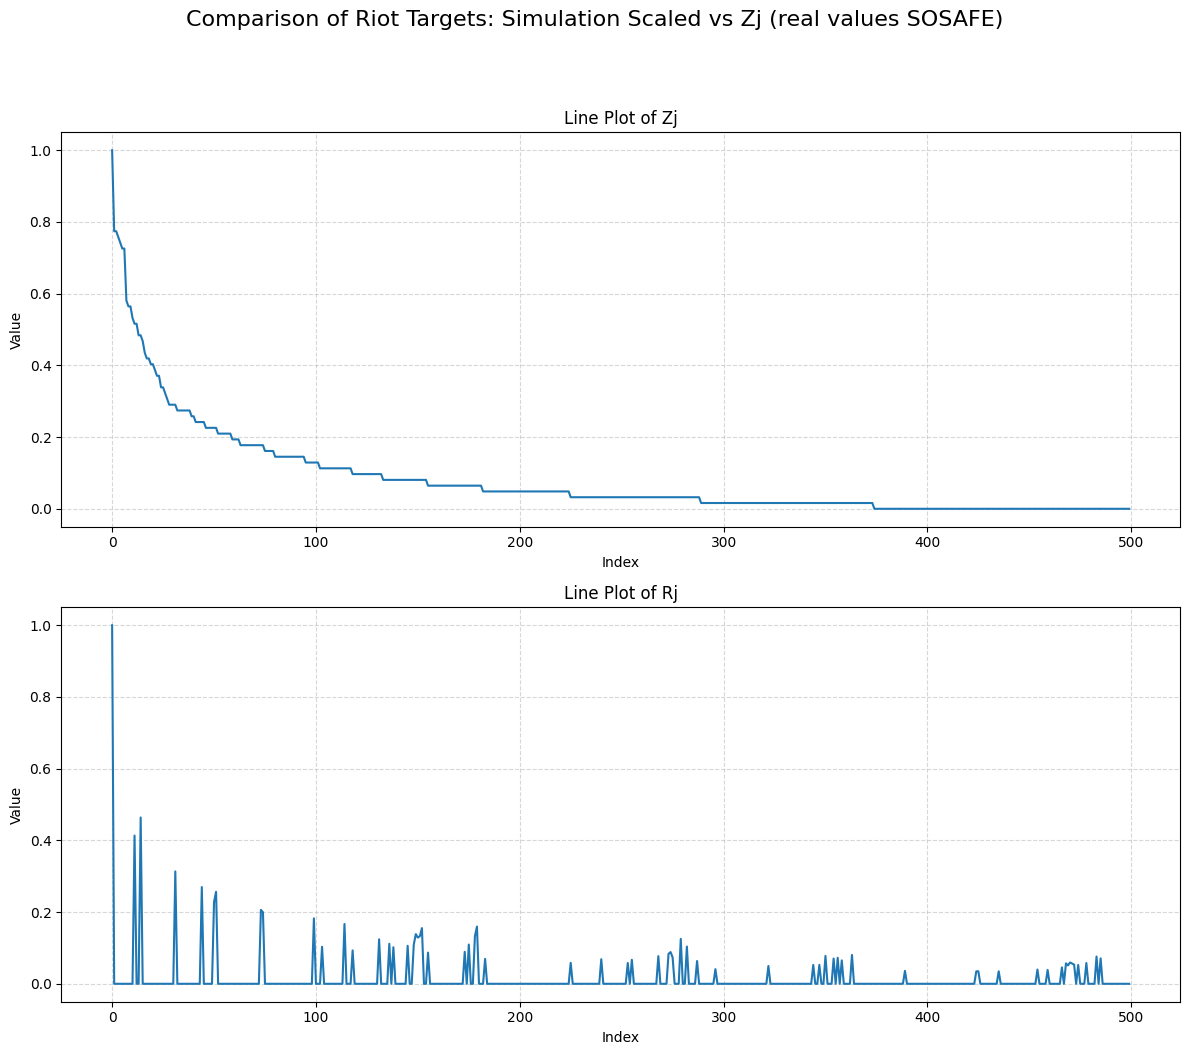

In [8]:
from sklearn.preprocessing import MinMaxScaler

def plot_results(Zj, Rj, algorithm):

    # Crear una figura con dos subplots verticales
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Agregar un título general
    fig.suptitle(f"Comparison of Riot Targets: Simulation {algorithm} vs Zj (real values SOSAFE)", fontsize=16, y=1.05)

    # Primer subplot para Zj
    x1 = np.arange(len(Zj))
    y1 = Zj
    ax1.plot(x1, y1)
    ax1.set_xlabel('Index')
    ax1.set_ylabel('Value')
    ax1.set_title('Line Plot of Zj')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Segundo subplot para Rj
    x2 = np.arange(len(Rj))
    y2 = Rj
    ax2.plot(x2, y2)
    ax2.set_xlabel('Index')
    ax2.set_ylabel('Value')
    ax2.set_title('Line Plot of Rj')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()


scaler = MinMaxScaler()

real_scaled_data = scaler.fit_transform(Zj[:, 2].reshape(-1, 1)).flatten()
sim_results_scaled_data = scaler.fit_transform(Rj.reshape(-1, 1)).flatten()

plot_results(real_scaled_data, sim_results_scaled_data, "Scaled")

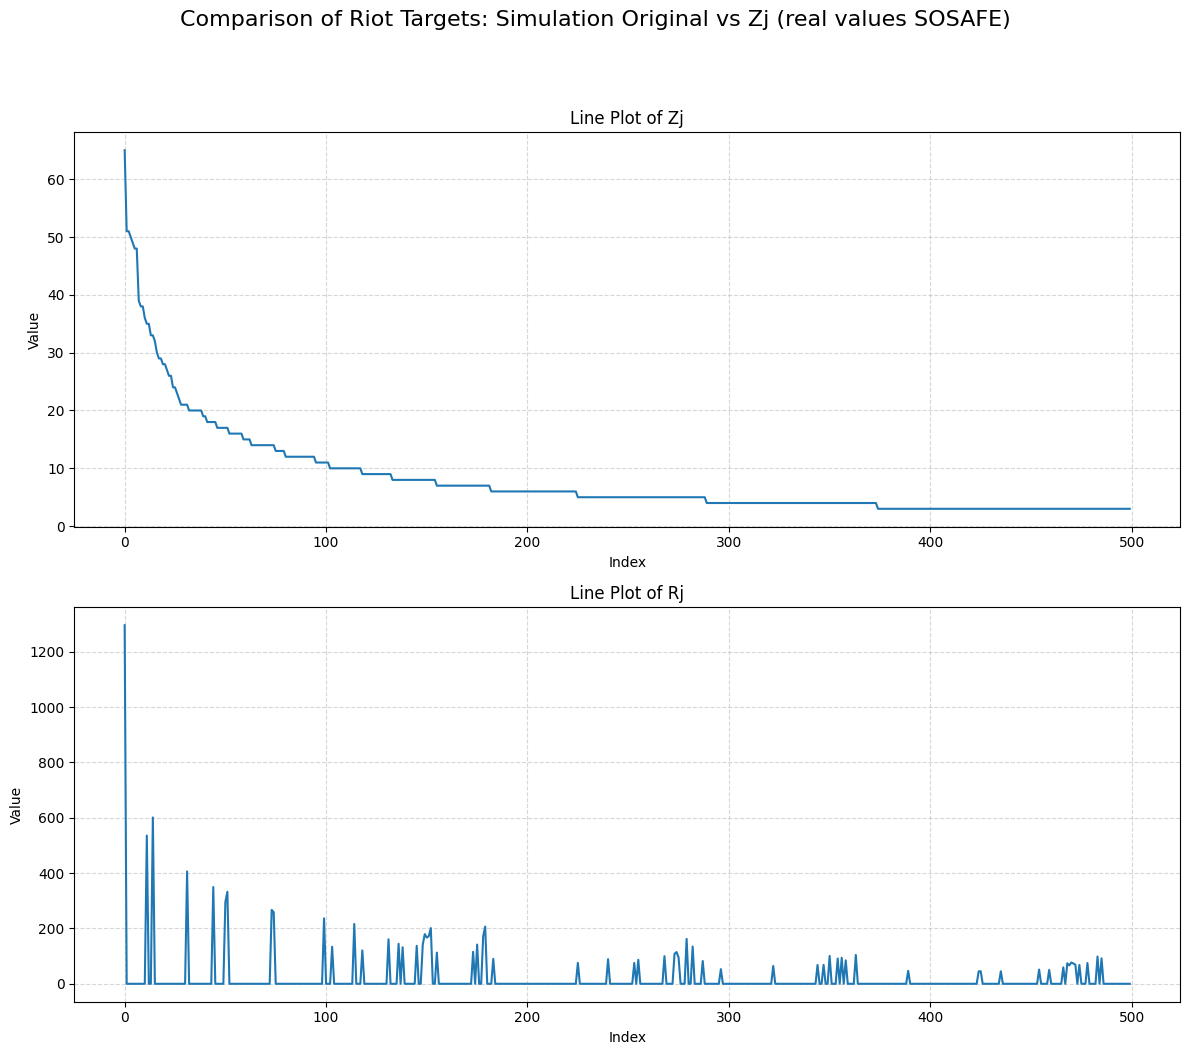

In [9]:
plot_results(Zj[:, 2], Rj, "Original")

## Cálculo de Métricas

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_errors_sklearn(predicted, real):
    predicted = predicted.flatten()
    real = real.flatten()

    mse = mean_squared_error(real, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(real, predicted)
    r2 = r2_score(real, predicted)

    # MAPE con manejo de valores cero
    # Calculamos MAPE solo para valores no cero
    non_zero_mask = (real != 0)
    if np.any(non_zero_mask):
        mape = np.mean(np.abs((real[non_zero_mask] - predicted[non_zero_mask]) / real[non_zero_mask])) * 100
    else:
        mape = np.nan  # o podrías establecer otro valor por defecto

    # SMAPE (Symmetric Mean Absolute Percentage Error)
    epsilon = 1e-10
    smape = np.mean(2 * np.abs(real - predicted) / (np.abs(real) + np.abs(predicted) + epsilon)) * 100

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "smape": smape,
        "r2": r2,
        "max_error": np.max(np.abs(real - predicted))
    }

    return metrics

def print_detailed_comparison_sklearn(predicted, real):
    metrics = calculate_errors_sklearn(predicted, real)

    print("Métricas de error:")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"MAPE mod: {metrics['mape']:.2f}%")
    print(f"SMAPE: {metrics['smape']:.2f}%")
    print(f"R² Score: {metrics['r2']:.4f}")
    print(f"Error máximo: {metrics['max_error']:.4f}")

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

real_scaled_data = scaler.fit_transform(Zj[:, 2].reshape(-1, 1)).flatten()
sim_results_scaled_data = scaler.fit_transform(Rj.reshape(-1, 1)).flatten()

print_detailed_comparison_sklearn(sim_results_scaled_data, real_scaled_data)

Métricas de error:
RMSE: 0.1452
MAE: 0.0776
MAPE mod: 101.21%
SMAPE: 142.30%
R² Score: -0.1818
Error máximo: 0.7742


In [12]:
!lscpu

Architecture:             x86_64
  CPU op-mode(s):         32-bit, 64-bit
  Address sizes:          46 bits physical, 48 bits virtual
  Byte Order:             Little Endian
CPU(s):                   2
  On-line CPU(s) list:    0,1
Vendor ID:                GenuineIntel
  Model name:             Intel(R) Xeon(R) CPU @ 2.20GHz
    CPU family:           6
    Model:                79
    Thread(s) per core:   2
    Core(s) per socket:   1
    Socket(s):            1
    Stepping:             0
    BogoMIPS:             4400.44
    Flags:                fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge m
                          ca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht sysc
                          all nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xt
                          opology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq
                           ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt
                           aes xsave avx f16c rdrand hypervisor 

In [13]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found
